**Design of Efficacious Drugs with Deep Learning**

**DeepPurpose** allows researchers to leverage deep learning to design more efficacious drugs. While designing drugs, researchers are most interested in the drugs binding affinity to a target (or a disease causing protein of interest) as well as the pharmacokinetics (PK) indices that
measure how the body reacts to the drug. PK indices can measure a drug's absorption, distribution, metabolism,
excretion, and toxicity (ADMET) in the body. **DeepPurpose** is a deep learning library for drug repurposing and virtual screening using PyTorch. 

The researcher can select from the pretrained deep learning models offered by DeepPurpose or train models of their own to fit their specific questions or research interests to form predictions. Based on the predictions of their drug-target interaction, the researcher may then alter the structure of the drug using their domain knowledge to improve the drugs effectiveness. The benefit of pretrained models is that researchers will receive immediate predictions about the drugs affinity and ADMET properties following structural alteration - bypassing the time consuming and costly wet chemistry experiments that would otherwise need to be performed. 

Link to the paper on arxiv: https://arxiv.org/pdf/2010.03951.pdf<br>
Link to DeepPurpose github page: https://github.com/kexinhuang12345/DeepPurpose<br>
- First, we install some packages necessary to implement DeepPurpose
- See Tutorial_1_DTI_Prediction, Tutorial_2_Drug_Property_Pred_Assay_Data for Environment Settings

**(data: load_antiviral_drug, load_broad_repurposing_hub, load_SARS_CoV2_Protease_3CL, BindingDB, Davis/KIBA‑like benchmarks)** 

In [2]:
#  1. SILENCE EVERYTHING FIRST (BEFORE ANY IMPORTS!)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'    # 0=all, 1=filter INFO, 2=filter WARNINGS, 3=ERROR ONLY
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN
os.environ['RDKIT_HAS_NO_WARNINGS'] = '1'   # RDKit silence
from pathlib import Path
# 2. NOW import everything
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Kill RDKit

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*weights_only=False.*")
# Suppress only this torch.load / weights_only warning
warnings.filterwarnings("ignore", message="You are using `torch.load` with `weights_only=False`")

import logging
# Silence DeepPurpose / compound property logging
logging.getLogger("DeepPurpose").setLevel(logging.ERROR)
logging.getLogger("CompoundPred").setLevel(logging.ERROR)
# or globally:
logging.getLogger().setLevel(logging.ERROR)

from DeepPurpose import utils, dataset, DTI as models
from DeepPurpose import utils, dataset, CompoundPred  # This DeepPurpose is the local directory
import tensorflow as tf
from DeepPurpose import DTI as models
from DeepPurpose.utils import *
from DeepPurpose.dataset import *

from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

################################
# DEEP PURPOSE ENV CONFIG
################################
# SEE Tutorial_2_Drug_Property_Pred_Assay_Data
# SEE Tutorial_1_DTI_Prediction-

# In Jupyter - # DEEP PURPOSE Test load, finds files automatically
# clone the DeepPurpose github page
#!git clone https://github.com/kexinhuang12345/DeepPurpose

# notebook "deep_repurpose"  uses:
# Install the following packages
#!pip install DeepPurpose
#!pip install rdkit
#!pip install git+https://github.com/bp-kelley/descriptastorus
#!pip install pandas-flavor
#!pip install gradio==3.28.1
#!pip install matplotlib

A real life researchers screen many different drugs against a target protein of interest (sometimes the number of drug compounds ranges into the millions). So entering information into DeepPurpose one-by-one isn't very efficient. However, once we have drug-target pairs with good binding affinities, we can remodel our drug to improve binding affinity and ADMET properties. 

### **Case-study #1**<br>
Here, we will consider the human breast cancer gene BRCA1. There has been some evidence that anti-viral drugs may be effective at slowing cancer cell growth. We will utilize DeepPurpose to run reporposing analysis of Broad Institute's repurposing drugs and anti-viral drugs datasets and will select the top 3 drugs for BRCA1 that have the highest binding affinity. We will then examine those drug-target combinations and play around with their structures to see if we can imporve binding affinity and ADMET properties.

In [3]:
# Using a DeepPurpose pre-trained model MPNN_CNN_DAVIS
# Load pretrained model from a model directory path
net = models.model_pretrained(model = 'MPNN_CNN_DAVIS')

# In this example, loading repurposing dataset using Antiviral drugs and the BRCA1 canonical amino acid sequence.
X_repurpose, drug_name, drug_cid = load_antiviral_drugs(".")
target, target_name = ('MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQCPLCKNDITKRSLQESTRFSQLVEELLKIICAFQLDTGLEYANSYNFAKKENNSPEHLKDEVSIIQSMGYRNRAKRLLQSEPENPSLQETSLSVQLSNLGTVRTLRTKQRIQPQKTSVYIELGSDSSEDTVNKATYCSVGDQELLQITPQGTRDEISLDSAKKAACEFSETDVTNTEHHQPSNNDLNTTEKRAAERHPEKYQGSSVSNLHVEPCGTNTHASSLQHENSSLLLTKDRMNVEKAEFCNKSKQPGLARSQHNRWAGSKETCNDRRTPSTEKKVDLNADPLCERKEWNKQKLPCSENPRDTEDVPWITLNSSIQKVNEWFSRSDELLGSDDSHDGESESNAKVADVLDVLNEVDEYSGSSEKIDLLASDPHEALICKSERVHSKSVESNIEDKIFGKTYRKKASLPNLSHVTENLIIGAFVTEPQIIQERPLTNKLKRKRRPTSGLHPEDFIKKADLAVQKTPEMINQGTNQTEQNGQVMNITNSGHENKTKGDSIQNEKNPNPIESLEKESAFKTKAEPISSSISNMELELNIHNSKAPKKNRLRRKSSTRHIHALELVVSRNLSPPNCTELQIDSCSSSEEIKKKKYNQMPVRHSRNLQLMEGKEPATGAKKSNKPNEQTSKRHDSDTFPELKLTNAPGSFTKCSNTSELKEFVNPSLPREEKEEKLETVKVSNNAEDPKDLMLSGERVLQTERSVESSSISLVPGTDYGTQESISLLEVSTLGKAKTEPNKCVSQCAAFENPKGLIHGCSKDNRNDTEGFKYPLGHEVNHSRETSIEMEESELDAQYLQNTFKVSKRQSFAPFSNPGNAEEECATFSAHSGSLKKQSPKVTFECEQKEENQGKNESNIKPVQTVNITAGFPVVGQKDKPVDNAKCSIKGGSRFCLSSQFRGNETGLITPNKHGLLQNPYRIPPLFPIKSFVKTKCKKNLLEENFEEHSMSPEREMGNENIPSTVSTISRNNIRENVFKEASSSNINEVGSSTNEVGSSINEIGSSDENIQAELGRNRGPKLNAMLRLGVLQPEVYKQSLPGSNCKHPEIKKQEYEEVVQTVNTDFSPYLISDNLEQPMGSSHASQVCSETPDDLLDDGEIKEDTSFAENDIKESSAVFSKSVQKGELSRSPSPFTHTHLAQGYRRGAKKLESSEENLSSEDEELPCFQHLLFGKVNNIPSQSTRHSTVATECLSKNTEENLLSLKNSLNDCSNQVILAKASQEHHLSEETKCSASLFSSQCSELEDLTANTNTQDPFLIGSSKQMRHQSESQGVGLSDKELVSDDEERGTGLEENNQEEQSMDSNLGEAASGCESETSVSEDCSGLSSQSDILTTQQRDTMQHNLIKLQQEMAELEAVLEQHGSQPSNSYPSIISDSSALEDLRNPEQSTSEKAVLTSQKSSEYPISQNPEGLSADKFEVSADSSTSKNKEPGVERSSPSKCPSLDDRWYMHSCSGSLQNRNYPSQEELIKVVDVEEQQLEESGPHDLTETSYLPRQDLEGTPYLESGISLFSDDPESDPSEDRAPESARVGNIPSSTSALKVPQLKVAESAQSPAAAHTTDTAGYNAMEESVSREKPELTASTERVNKRMSMVVSGLTPEEFMLVYKFARKHHITLTNLITEETTHVVMKTDAEFVCERTLKYFLGIAGGKWVVSYFWVTQSIKERKMLNEHDFEVRGDVVNGRNHQGPKRARESQDRKIFRGLEICCYGPFTNMPTDQLEWMVQLCGASVVKELSSFTLGTGVHPIVVVQPDAWTEDNGFHAIGQMCEAPVVTREWVLDSVALYQCQELDTYLIPQIPHSHYMDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQCPLCKNDITKRSLQESTRFSQLVEELLKIICAFQLDTGLEYANSYNFAKKENNSPEHLKDEVSIIQSMGYRNRAKRLLQSEPENPSLQETSLSVQLSNLGTVRTLRTKQRIQPQKTSVYIELGSDSSEDTVNKATYCSVGDQELLQITPQGTRDEISLDSAKKAACEFSETDVTNTEHHQPSNNDLNTTEKRAAERHPEKYQGSSVSNLHVEPCGTNTHASSLQHENSSLLLTKDRMNVEKAEFCNKSKQPGLARSQHNRWAGSKETCNDRRTPSTEKKVDLNADPLCERKEWNKQKLPCSENPRDTEDVPWITLNSSIQKVNEWFSRSDELLGSDDSHDGESESNAKVADVLDVLNEVDEYSGSSEKIDLLASDPHEALICKSERVHSKSVESNIEDKIFGKTYRKKASLPNLSHVTENLIIGAFVTEPQIIQERPLTNKLKRKRRPTSGLHPEDFIKKADLAVQKTPEMINQGTNQTEQNGQVMNITNSGHENKTKGDSIQNEKNPNPIESLEKESAFKTKAEPISSSISNMELELNIHNSKAPKKNRLRRKSSTRHIHALELVVSRNLSPPNCTELQIDSCSSSEEIKKKKYNQMPVRHSRNLQLMEGKEPATGAKKSNKPNEQTSKRHDSDTFPELKLTNAPGSFTKCSNTSELKEFVNPSLPREEKEEKLETVKVSNNAEDPKDLMLSGERVLQTERSVESSSISLVPGTDYGTQESISLLEVSTLGKAKTEPNKCVSQCAAFENPKGLIHGCSKDNRNDTEGFKYPLGHEVNHSRETSIEMEESELDAQYLQNTFKVSKRQSFAPFSNPGNAEEECATFSAHSGSLKKQSPKVTFECEQKEENQGKNESNIKPVQTVNITAGFPVVGQKDKPVDNAKCSIKGGSRFCLSSQFRGNETGLITPNKHGLLQNPYRIPPLFPIKSFVKTKCKKNLLEENFEEHSMSPEREMGNENIPSTVSTISRNNIRENVFKEASSSNINEVGSSTNEVGSSINEIGSSDENIQAELGRNRGPKLNAMLRLGVLQPEVYKQSLPGSNCKHPEIKKQEYEEVVQTVNTDFSPYLISDNLEQPMGSSHASQVCSETPDDLLDDGEIKEDTSFAENDIKESSAVFSKSVQKGELSRSPSPFTHTHLAQGYRRGAKKLESSEENLSSEDEELPCFQHLLFGKVNNIPSQSTRHSTVATECLSKNTEENLLSLKNSLNDCSNQVILAKASQEHHLSEETKCSASLFSSQCSELEDLTANTNTQDPFLIGSSKQMRHQSESQGVGLSDKELVSDDEERGTGLEENNQEEQSMDSNLGEAASGCESETSVSEDCSGLSSQSDILTTQQRDTMQHNLIKLQQEMAELEAVLEQHGSQPSNSYPSIISDSSALEDLRNPEQSTSEKAVLTSQKSSEYPISQNPEGLSADKFEVSADSSTSKNKEPGVERSSPSKCPSLDDRWYMHSCSGSLQNRNYPSQEELIKVVDVEEQQLEESGPHDLTETSYLPRQDLEGTPYLESGISLFSDDPESDPSEDRAPESARVGNIPSSTSALKVPQLKVAESAQSPAAAHTTDTAGYNAMEESVSREKPELTASTERVNKRMSMVVSGLTPEEFMLVYKFARKHHITLTNLITEETTHVVMKTDAEFVCERTLKYFLGIAGGKWVVSYFWVTQSIKERKMLNEHDFEVRGDVVNGRNHQGPKRARESQDRKIFRGLEICCYGPFTNMPTDQLEWMVQLCGASVVKELSSFTLGTGVHPIVVVQPDAWTEDNGFHAIGQMCEAPVVTREWVLDSVALYQCQELDTYLIPQIPHSHY',
                       'HUMAN_BRACA1, P38398-1')

_ = models.repurpose(X_repurpose, target, net, drug_name, target_name,
                         result_folder = "./result/", convert_y = True)

Dataset already downloaded in the local system...
repurposing...
Drug Target Interaction Prediction Mode...
in total: 82 drug-target pairs
encoding drug...
unique drugs: 81
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Drug Repurposing Result for HUMAN_BRACA1, P38398-1
+------+----------------------+------------------------+---------------+
| Rank |      Drug Name       |      Target Name       | Binding Score |
+------+----------------------+------------------------+---------------+
|  1   |     Ganciclovir      | HUMAN_BRACA1, P38398-1 |      0.00     |
|  2   |     Famciclovir      | HUMAN_BRACA1, P38398-1 |      0.00     |
|  3   |      Vidarabine      | HUMAN_BRACA1, P38398-1 |      0.00     |
|  4   |     Chloroquine      | HUMAN_BRACA1, P38398-1 |      0.19     |
|  5   |       Inosine        | HUMAN_BRACA1, P38398-1 |      0.23     |
|  6   |     Dolutegravir     | HUMAN_BRACA1, P38398-1 |      0.90     |
|  7   |      Edoxudine       | HUMAN

The **top 3 <font color="#DC143C">anti-viral drugs</font> for binding BRCA1 in Case-study#1 are:**

1. Sofosbuvir
2. Indinavir 
3. Doravirine 

**<font color="#DC143C">The larger the binding score, the greater the predicted binding affinity of the ligand (drug) to its target.</font>** 
- Therefore, drugs with higher binding scores are ranked more favorably as potential binders.
- All three of these **antiviral drugs** **(Ganciclovir, Famciclovir, and Vidarabine) have binding **scores of zero**, which indicates that the **model predicts very low or negligible binding affinity to BRCA1, a cancer target** [BRCA1 details](https://www.proteinatlas.org/ENSG00000012048-BRCA1)
- Many of the Case-study#2 <font color="#DC143C">**Broad repurposing drugs**</font> also had binding **scores of zero**, which suggests that they do not show strong predicted interaction with BRCA1 in this model.
- In total, the **viral‑drug dataset contained 81 drugs**, and the **Broad repurposing hub dataset contained 6,111 drugs**

Let's take a look at the structure of these drugs.<br>
First, we will get the canonical SMILE texts from 
    Ganciclovir: C1=NC2=C(N1COC(CO)CO)N=C(NC2=O)N<br>
    Famciclovir: CC(=O)OCC(CCN1C=NC2=CN=C(N=C21)N)COC(=O)C<br>
    Vidarabine: C1=NC(=C2C(=N1)N(C=N2)C3C(C(C(O3)CO)O)O)N


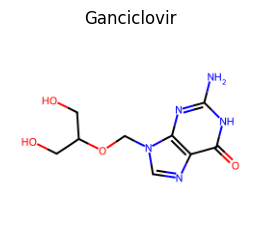

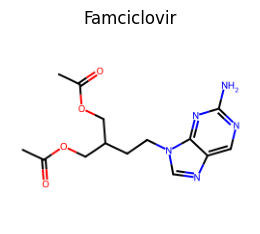

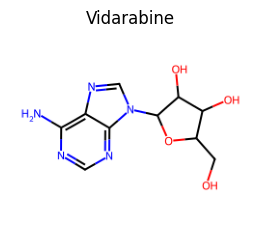

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
# If MolToMPL is not available
# Replace MolToMPL with MolToImage (works everywhere):

def draw_mol(smiles, title, size=(250, 200)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        img = Draw.MolToImage(mol, size=size)
        plt.figure(figsize=(3.5, 2.5))
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    else:
        print(f"Invalid SMILES: {title}")

# same three calls as above

# 1. Ganciclovir
draw_mol('C1=NC2=C(N1COC(CO)CO)N=C(NC2=O)N', 'Ganciclovir')
plt.show()

# 2. Famciclovir
draw_mol('CC(=O)OCC(CCN1C=NC2=CN=C(N=C21)N)COC(=O)C', 'Famciclovir')
plt.show()

# 3. Vidarabine
draw_mol('C1=NC(=C2C(=N1)N(C=N2)C3C(C(C(O3)CO)O)O)N', 'Vidarabine')
plt.show()


### Drugs above, share common features, which explains why they bind to Antiviral Targets (HIV, SARS) with higher affinity than BRCA1.

### **Interpreting DeepPurpose drug‑repurposing / virtual‑screening Binding Scores**
- **High binding score** → the model thinks that drug is a **stronger / more likely binder** to the target (for your ranking).  
- **Low binding score** → weaker / less likely interaction according to the model
  
**Ganciclovir, Famciclovir, Vidarabine, and Chloroquine** low binding scores, which means this BRCA1 model does **not** predict them to be strong binders
**Sofosbuvir (15.95)** is the “best” ranked hit among these, but even that is not a strong signal compared to typical high‑affinity hits in other DTI studies
| Rank |      Drug Name       |      Target Name       | Binding Score |
|------|----------------------|------------------------|---------------|
|  1   |     Ganciclovir      | HUMAN_BRACA1, P38398-1 |      0.00     |
| 10  |      Sofosbuvir      | HUMAN_BRACA1, P38398-1 |     15.95     |

- **See Tutorial_1_DTI_Prediction for SARS Covid spike Protein Target against antiviral drugs**
- **Compare BRACA1 results to SARS Binding Scores or HIV**


### **Case-study #2**<br>
Let's also take a look at the only approved anti-viral drug for COVID-19, Remdesivir.

Remdesivir SMILES: CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4
                                                          
See PubChem link: https://pubchem.ncbi.nlm.nih.gov/compound/Remdesivir

Remdesivir has an active metabolite called GS-441524. It will be interesting to see the differences in predicted binding affinity and ADMET properties between the drug and its active metabolite. 

See link to major active metabolite of the drug GS-441524: https://www.guidetopharmacology.org/GRAC/LigandDisplayForward?ligandId=10715

Below let's take a look at the structure of Remdesivir and GS-441524. As you will see from the structures - the active metaboite is part of the drug. The drug contains other atoms and functional groups along with the active metabolite, which perhaps makes it effective as a drug.

**Draw.MolToImage is part of the core rdkit.Chem.Draw and will work everywhere**
In practice, for maximum compatibility, stick with (MolToImage + plt.imshow) unless you specifically need the vector‑style MolToMPL output.
- **MolToMPL exists in some RDKit distributions (e.g., via conda on Linux/macOS), but not all** (especially on some wheels or older versions).
- If you want MolToMPL specifically, ensure you have a recent RDKit installed via conda:
- conda install -c conda-forge rdkit

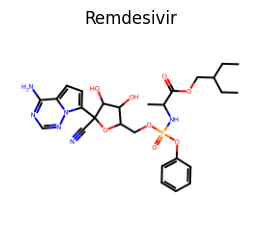

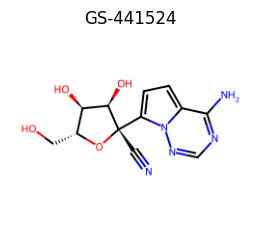

In [5]:
def draw_mol(smiles, title, size=(250, 200)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        img = Draw.MolToImage(mol, size=size)
        plt.figure(figsize=(3.5, 2.5))
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    else:
        print(f"Invalid SMILES: {title}")

# Remdesivir structure
draw_mol('CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4', 'Remdesivir')

# GS-441524 structure
draw_mol('OC[C@H]1O[C@@]([C@@H]([C@@H]1O)O)(C#N)c1ccc2n1ncnc2N', 'GS-441524')
plt.show()

### Be care about overriding data in result folder!

In [6]:
# Here is the amino acid sequence for SARS CoV2 protease from DeepPurpose
load_SARS_CoV2_Protease_3CL()[0]

'SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQ'

In [7]:
import numpy as np
from DeepPurpose import utils, DTI, CompoundPred

aa_seq = {
    'SARS CoV2 Protease': 'SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQ',
    'BRCA1': 'MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDEVLAEGGFAIVFLVRTSNGMKCALKRMFVNNEHDLQVCKREIQIMRDLSGHKNIVGYIDSSINNVSSGDVWEVLILMDFCRGGQVVNLMNQRLQTGFTENEVLQIFCDTCEAVARLHQCKTPIIHRDLKVENILLHDRGHYVLCDFGSATNKFQNPQTEGVNAVEDEIKKYTTLSYRAPEMVNLYSGKIITTKADIWALGCLLYKLCYFTLPFGESQVAICDGNFTIPDNSRYSQDMHCLIRYMLEPDPDKRPDIYQVSYFSFKLLKKECPIPNVQNSPIPAKLPEPVKASEAAAKKTQPKARLTDPIPTTETSIAPRQRPKAGQTQPNPGILPIQPALTPRKRATVQPPPQAAGSSNQPGLLASVPQPKPQAPPSQPLPQTQAKQPQAPPTPQQTPSTQAQGLPAQAQATPQHQQQLFLKQQQQQQQPPPAQQQPAGTFYQQQQAQTQQFQAVHPATQKPAIAQFPVVSQGGSQQQLMQNFYQQQQQQQQQQQQQQLATALHQQQLMTQQAALQQKPTMAAGQQPQPQPAAAPQPAPAQEPAIQAPVRQQPKVQTTPPPAVQGQKVGSLTPPSSPKTQRAGHRRILSDVTHSAVFGVPASKSTQLLQAAAAEASLNKSKSATTTPSGSPRTSQQNVYNPSEGSTWNPFDDDNFSKLTAEELLNKDFAKLGEGKHPEKLGGSAESLIPGFQSTQGDAFATTSFSAGTAEKRKGGQTVDSGLPLLSVSDPFIPLQVPDAPEKLIEGLKSPDTSLLLPDLLPMTDPFGSTSDAVIEKADVAVESLIPGLEPPVPQRLPSQTESVTSNRTDSLTGEDSLLDCSLLSNPTTDLLEEFAPTAISAPVHKAAEDSNLISGFDVPEGSDKVAEDEFDPIPVLITKNPQGGHSRNSSGSSESSLPNLARSLLLVDQLIDL'
    
}


def DTI_pred(drug, target, drug_encoding, target_encoding, model):

    target = aa_seq[target]
    X_pred = utils.data_process(X_drug = [drug], X_target = [target], y = [0],
                                drug_encoding = drug_encoding, target_encoding = target_encoding, 
                                split_method='no_split')
    y_pred = model.predict(X_pred)[0]
    y_pred = 10**(-y_pred) / 1e-9
    return f'{y_pred:.2f} nM'


def ADMET_pred(drug, ADMET_model_type, task, unit):
    model = model_ADMETs[task + '_' + ADMET_model_type + '_model']
    X_pred = utils.data_process(X_drug = [drug], y = [0],
                                drug_encoding = ADMET_model_type, 
                                split_method='no_split')
    y_pred = model.predict(X_pred)[0]
    
    if unit == '%':
        y_pred = y_pred*100
    
    return f'{y_pred:.2f} ' + unit

model_DTIs = {
    'CNN-CNN': DTI.model_pretrained(model = 'CNN_CNN_BindingDB'),
    'MPNN-CNN': DTI.model_pretrained(model = 'MPNN_CNN_BindingDB'),
    'Morgan-CNN': DTI.model_pretrained(model = 'Morgan_CNN_BindingDB'),
    'Morgan-AAC': DTI.model_pretrained(model = 'Morgan_AAC_BindingDB'),
    'Daylight-AAC': DTI.model_pretrained(model = 'Daylight_AAC_BindingDB'),
}

model_ADMETs = {}

for ADMET_model_type in ['MPNN', 'CNN', 'Morgan']:
    for task in ['AqSolDB', 'Caco2', 'HIA', 'Pgp_inhibitor', 'Bioavailability', 'BBB_MolNet', 'PPBR', 'CYP2C19', 'CYP2D6', 'CYP3A4', 'CYP1A2', 'CYP2C9', 'ClinTox', 'Lipo_AZ', 'Half_life_eDrug3D', 'Clearance_eDrug3D']:
        model_ADMETs[task + '_' + ADMET_model_type + '_model'] = CompoundPred.model_pretrained(model = task + '_' + ADMET_model_type + '_model')
        
def chem(amino_acid_sequence, molecule, affinity_model_type, ADMET_model_type):
    # affinity scores
    if len(amino_acid_sequence) > 0:
        # there is AMINO ACID SEQUENCE INPUT
        model_DTI = model_DTIs[affinity_model_type]
        affinity = DTI_pred(molecule, amino_acid_sequence, affinity_model_type.split('-')[0], affinity_model_type.split('-')[1], model_DTI)
    else:
        affinity = 'Missing Amino Acid Sequence, no Binding Affinity is predicted'
    
    ADMET = {}
    # physiochem
    solubility = ADMET_pred(molecule, ADMET_model_type, 'AqSolDB', 'log mol/L')
    Lipophilicity = ADMET_pred(molecule, ADMET_model_type, 'Lipo_AZ', '(log-ratio)')
    physiochem = {'Solubility': solubility, 'Lipophilicity': Lipophilicity}
    ADMET.update(physiochem)

    # absorption
    Caco2 = ADMET_pred(molecule, ADMET_model_type, 'Caco2', 'cm/s')
    HIA = ADMET_pred(molecule, ADMET_model_type, 'HIA', '%')
    Pgp = ADMET_pred(molecule, ADMET_model_type, 'Pgp_inhibitor', '%')
    bioavail = ADMET_pred(molecule, ADMET_model_type, 'Bioavailability', '%')
    
    absorption = {'(Absorption) Caco-2': Caco2, '(Absorption) HIA': HIA, '(Absorption) Pgp': Pgp, '(Absorption) Bioavailability F20': bioavail}
    ADMET.update(absorption)
    
    # distribution
    BBB = ADMET_pred(molecule, ADMET_model_type, 'BBB_MolNet', '%')
    PPBR = ADMET_pred(molecule, ADMET_model_type, 'PPBR', '%')

    distribution = {'(Distribution) BBB': BBB, '(Distribution) PPBR': PPBR}
    ADMET.update(distribution)
    
    # Metabolism
    CYP2C19 = ADMET_pred(molecule, ADMET_model_type, 'CYP2C19', '%')
    CYP2D6 = ADMET_pred(molecule, ADMET_model_type, 'CYP2D6', '%')
    CYP3A4 = ADMET_pred(molecule, ADMET_model_type, 'CYP3A4', '%')
    CYP1A2 = ADMET_pred(molecule, ADMET_model_type, 'CYP1A2', '%')
    CYP2C9 = ADMET_pred(molecule, ADMET_model_type, 'CYP2C9', '%')
    
    metabolism = {'(Metabolism) CYP2C19': CYP2C19, '(Metabolism) CYP2D6': CYP2D6, '(Metabolism) CYP3A4': CYP3A4, '(Metabolism) CYP1A2': CYP1A2, '(Metabolism) CYP2C9': CYP2C9}
    ADMET.update(metabolism)
    
    # Execretion
    Half_life = ADMET_pred(molecule, ADMET_model_type, 'Half_life_eDrug3D', 'h')
    Clearance = ADMET_pred(molecule, ADMET_model_type, 'Clearance_eDrug3D', 'mL/min/kg')
        
    execretion = {'(Execretion) Half life': Half_life, '(Execretion) Clearance': Clearance}
    ADMET.update(execretion)
    
    # Clinical Toxicity
    toxicity = ADMET_pred(molecule, ADMET_model_type, 'ClinTox', '%')
        
    clinical_toxicity = {'Clinical Toxicity': toxicity}
    ADMET.update(clinical_toxicity)
    
    return affinity, ADMET



Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...


### Read File repurposing.txt, Show Top Binding Scores

In [8]:
import os

result_file = "./result/repurposing.txt"

if not os.path.exists(result_file):
    print("No repurposing result file found at ./result/repurposing.txt")
    exit()

with open(result_file, "r") as f:
    lines = [line.rstrip("\n") for line in f.readlines()]

# --- 1. SKIP HEADER / underline rows ---
# Expect lines like:
#  0: '+------+----------------------+------------------------+---------------+'
#  1: '| Rank | Drug Name | Target Name | Binding Score |'
#  2: '+------+----------------------+------------------------+---------------+'
#  3: '|  1   | Ganciclovir | ... | 0.00 |'
#
# Keep all lines that look like '| ... | ... |'
data_lines = [
    ln for ln in lines
    if ln.startswith('|') and ln.endswith('|')
]

if len(data_lines) == 0:
    print("No data rows found in repurposing.txt (no pipes).")
    exit()

rows = []  # (score, rank, drug_name, target_name)

for line in data_lines:
    # remove outer | and strip
    clean = line.strip('|').strip()
    # split on '|'
    fields = [x.strip() for x in clean.split('|')]
    if len(fields) < 4:
        continue

    rank_str = fields[0].strip()
    drug_name_str = fields[1].strip()
    target_name_str = fields[2].strip()
    score_str = fields[3].strip()

    try:
        rank = int(rank_str)
        score = float(score_str)
        rows.append((score, rank, drug_name_str, target_name_str))
    except (ValueError, IndexError) as ex:
        print(f"Skipping malformed line: {line!r}")
        continue

if len(rows) == 0:
    print("No valid rows parsed from repurposing.txt (rank/score not numeric).")
    exit()

# --- 2. SORT BY SCORE ASCENDING, TAIL 25 ---
rows.sort(key=lambda x: x[0])      # ascending by binding score
tail_25 = rows[-25:]               # 25 highest scores

# --- 3. PRINT MARKDOWN TABLE ---
print("### Top 25 Drugs by Highest Binding Score (Ascending‑sorted tail)")
print()
print("| Rank | Drug Name | Target Name | Binding Score |")
print("|------|-----------|-------------|----------------|")

for score, rank, drug, target in tail_25:
    print(f"| {rank} | {drug} | {target} | {score:.2f} |")

Skipping malformed line: '| Rank |      Drug Name       |      Target Name       | Binding Score |'
### Top 25 Drugs by Highest Binding Score (Ascending‑sorted tail)

| Rank | Drug Name | Target Name | Binding Score |
|------|-----------|-------------|----------------|
| 58 | Zidovudine | HUMAN_BRACA1, P38398-1 | 59160.49 |
| 59 | Trifluridine | HUMAN_BRACA1, P38398-1 | 60693.29 |
| 60 | Nevirapine | HUMAN_BRACA1, P38398-1 | 67757.43 |
| 61 | Maraviroc | HUMAN_BRACA1, P38398-1 | 72384.23 |
| 62 | Methisazone | HUMAN_BRACA1, P38398-1 | 100762.35 |
| 63 | Simeprevir | HUMAN_BRACA1, P38398-1 | 110377.98 |
| 64 | Didanosine | HUMAN_BRACA1, P38398-1 | 156269.21 |
| 65 | Telbivudine | HUMAN_BRACA1, P38398-1 | 223121.17 |
| 66 | Delavirdine | HUMAN_BRACA1, P38398-1 | 268293.61 |
| 67 | Grazoprevir | HUMAN_BRACA1, P38398-1 | 371836.96 |
| 68 | Cobicistat | HUMAN_BRACA1, P38398-1 | 545375.08 |
| 69 | Entecavir | HUMAN_BRACA1, P38398-1 | 615873.02 |
| 70 | Podophyllotoxin | HUMAN_BRACA1, P38398-

### We observe good binding to BRACA1 target with antiviral drugs
Drugs **Simeprevir, Hydroxychloroquine,** and **Remdesivir** further up list (ASC ranked) **have high binding scores to BRCA1 and SARS targets**

**Interesting that  Hydroxychloroquine binds better to BRCA1 cancer target, as well as Remdesivir etc. used in week09 tutorials** 
- | 63 | Simeprevir | HUMAN_BRACA1, P38398-1 | 110377.86 |
- | 80 | Hydroxychloroquine | HUMAN_BRACA1, P38398-1 | 7648733.09 |

In [9]:
# Using a DeepPurpose pre-trained model and Broad Institute antiviral dataset
from DeepPurpose import DTI as models
from DeepPurpose.utils import *
from DeepPurpose.dataset import *
import os

# Load pretrained model
model = models.model_pretrained(model='MPNN_CNN_DAVIS')

# Load Broad Repurposing Hub + BRCA1
X_repurpose, drug_name, drug_cid = load_broad_repurposing_hub(".")

target, target_name = (
    'MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQCPLCKNDITKRSLQESTRFSQLVEELLKIICAFQLDTGLEYANSYNFAKKENNSPEHLKDEVSIIQSMGYRNRAKRLLQSEPENPSLQETSLSVQLSNLGTVRTLRTKQRIQPQKTSVYIELGSDSSEDTVNKATYCSVGDQELLQITPQGTRDEISLDSAKKAACEFSETDVTNTEHHQPSNNDLNTTEKRAAERHPEKYQGSSVSNLHVEPCGTNTHASSLQHENSSLLLTKDRMNVEKAEFCNKSKQPGLARSQHNRWAGSKETCNDRRTPSTEKKVDLNADPLCERKEWNKQKLPCSENPRDTEDVPWITLNSSIQKVNEWFSRSDELLGSDDSHDGESESNAKVADVLDVLNEVDEYSGSSEKIDLLASDPHEALICKSERVHSKSVESNIEDKIFGKTYRKKASLPNLSHVTENLIIGAFVTEPQIIQERPLTNKLKRKRRPTSGLHPEDFIKKADLAVQKTPEMINQGTNQTEQNGQVMNITNSGHENKTKGDSIQNEKNPNPIESLEKESAFKTKAEPISSSISNMELELNIHNSKAPKKNRLRRKSSTRHIHALELVVSRNLSPPNCTELQIDSCSSSEEIKKKKYNQMPVRHSRNLQLMEGKEPATGAKKSNKPNEQTSKRHDSDTFPELKLTNAPGSFTKCSNTSELKEFVNPSLPREEKEEKLETVKVSNNAEDPKDLMLSGERVLQTERSVESSSISLVPGTDYGTQESISLLEVSTLGKAKTEPNKCVSQCAAFENPKGLIHGCSKDNRNDTEGFKYPLGHEVNHSRETSIEMEESELDAQYLQNTFKVSKRQSFAPFSNPGNAEEECATFSAHSGSLKKQSPKVTFECEQKEENQGKNESNIKPVQTVNITAGFPVVGQKDKPVDNAKCSIKGGSRFCLSSQFRGNETGLITPNKHGLLQNPYRIPPLFPIKSFVKTKCKKNLLEENFEEHSMSPEREMGNENIPSTVSTISRNNIRENVFKEASSSNINEVGSSTNEVGSSINEIGSSDENIQAELGRNRGPKLNAMLRLGVLQPEVYKQSLPGSNCKHPEIKKQEYEEVVQTVNTDFSPYLISDNLEQPMGSSHASQVCSETPDDLLDDGEIKEDTSFAENDIKESSAVFSKSVQKGELSRSPSPFTHTHLAQGYRRGAKKLESSEENLSSEDEELPCFQHLLFGKVNNIPSQSTRHSTVATECLSKNTEENLLSLKNSLNDCSNQVILAKASQEHHLSEETKCSASLFSSQCSELEDLTANTNTQDPFLIGSSKQMRHQSESQGVGLSDKELVSDDEERGTGLEENNQEEQSMDSNLGEAASGCESETSVSEDCSGLSSQSDILTTQQRDTMQHNLIKLQQEMAELEAVLEQHGSQPSNSYPSIISDSSALEDLRNPEQSTSEKAVLTSQKSSEYPISQNPEGLSADKFEVSADSSTSKNKEPGVERSSPSKCPSLDDRWYMHSCSGSLQNRNYPSQEELIKVVDVEEQQLEESGPHDLTETSYLPRQDLEGTPYLESGISLFSDDPESDPSEDRAPESARVGNIPSSTSALKVPQLKVAESAQSPAAAHTTDTAGYNAMEESVSREKPELTASTERVNKRMSMVVSGLTPEEFMLVYKFARKHHITLTNLITEETTHVVMKTDAEFVCERTLKYFLGIAGGKWVVSYFWVTQSIKERKMLNEHDFEVRGDVVNGRNHQGPKRARESQDRKIFRGLEICCYGPFTNMPTDQLEWMVQLCGASVVKELSSFTLGTGVHPIVVVQPDAWTEDNGFHAIGQMCEAPVVTREWVLDSVALYQCQELDTYLIPQIPHSHYMDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQCPLCKNDITKRSLQESTRFSQLVEELLKIICAFQLDTGLEYANSYNFAKKENNSPEHLKDEVSIIQSMGYRNRAKRLLQSEPENPSLQETSLSVQLSNLGTVRTLRTKQRIQPQKTSVYIELGSDSSEDTVNKATYCSVGDQELLQITPQGTRDEISLDSAKKAACEFSETDVTNTEHHQPSNNDLNTTEKRAAERHPEKYQGSSVSNLHVEPCGTNTHASSLQHENSSLLLTKDRMNVEKAEFCNKSKQPGLARSQHNRWAGSKETCNDRRTPSTEKKVDLNADPLCERKEWNKQKLPCSENPRDTEDVPWITLNSSIQKVNEWFSRSDELLGSDDSHDGESESNAKVADVLDVLNEVDEYSGSSEKIDLLASDPHEALICKSERVHSKSVESNIEDKIFGKTYRKKASLPNLSHVTENLIIGAFVTEPQIIQERPLTNKLKRKRRPTSGLHPEDFIKKADLAVQKTPEMINQGTNQTEQNGQVMNITNSGHENKTKGDSIQNEKNPNPIESLEKESAFKTKAEPISSSISNMELELNIHNSKAPKKNRLRRKSSTRHIHALELVVSRNLSPPNCTELQIDSCSSSEEIKKKKYNQMPVRHSRNLQLMEGKEPATGAKKSNKPNEQTSKRHDSDTFPELKLTNAPGSFTKCSNTSELKEFVNPSLPREEKEEKLETVKVSNNAEDPKDLMLSGERVLQTERSVESSSISLVPGTDYGTQESISLLEVSTLGKAKTEPNKCVSQCAAFENPKGLIHGCSKDNRNDTEGFKYPLGHEVNHSRETSIEMEESELDAQYLQNTFKVSKRQSFAPFSNPGNAEEECATFSAHSGSLKKQSPKVTFECEQKEENQGKNESNIKPVQTVNITAGFPVVGQKDKPVDNAKCSIKGGSRFCLSSQFRGNETGLITPNKHGLLQNPYRIPPLFPIKSFVKTKCKKNLLEENFEEHSMSPEREMGNENIPSTVSTISRNNIRENVFKEASSSNINEVGSSTNEVGSSINEIGSSDENIQAELGRNRGPKLNAMLRLGVLQPEVYKQSLPGSNCKHPEIKKQEYEEVVQTVNTDFSPYLISDNLEQPMGSSHASQVCSETPDDLLDDGEIKEDTSFAENDIKESSAVFSKSVQKGELSRSPSPFTHTHLAQGYRRGAKKLESSEENLSSEDEELPCFQHLLFGKVNNIPSQSTRHSTVATECLSKNTEENLLSLKNSLNDCSNQVILAKASQEHHLSEETKCSASLFSSQCSELEDLTANTNTQDPFLIGSSKQMRHQSESQGVGLSDKELVSDDEERGTGLEENNQEEQSMDSNLGEAASGCESETSVSEDCSGLSSQSDILTTQQRDTMQHNLIKLQQEMAELEAVLEQHGSQPSNSYPSIISDSSALEDLRNPEQSTSEKAVLTSQKSSEYPISQNPEGLSADKFEVSADSSTSKNKEPGVERSSPSKCPSLDDRWYMHSCSGSLQNRNYPSQEELIKVVDVEEQQLEESGPHDLTETSYLPRQDLEGTPYLESGISLFSDDPESDPSEDRAPESARVGNIPSSTSALKVPQLKVAESAQSPAAAHTTDTAGYNAMEESVSREKPELTASTERVNKRMSMVVSGLTPEEFMLVYKFARKHHITLTNLITEETTHVVMKTDAEFVCERTLKYFLGIAGGKWVVSYFWVTQSIKERKMLNEHDFEVRGDVVNGRNHQGPKRARESQDRKIFRGLEICCYGPFTNMPTDQLEWMVQLCGASVVKELSSFTLGTGVHPIVVVQPDAWTEDNGFHAIGQMCEAPVVTREWVLDSVALYQCQELDTYLIPQIPHSHY',
    'HUMAN_BRACA1, P38398-1'
)

# Run repurposing and save to ./result/
_ = models.repurpose(X_repurpose, target, model, drug_name, target_name,
                     result_folder="./result/", convert_y=True)

# === PRINT ONLY ROWS WITH Binding Score > 0 (from top section of file) ===
result_file = "./result/repurposing.txt"

if os.path.exists(result_file):
    with open(result_file, "r") as f:
        lines = [line.rstrip() for line in f.readlines()]

    # Keep header + underline (first 2 rows)
    header = lines[0] if len(lines) > 0 else ""
    underline = lines[1] if len(lines) > 1 else ""

    # Process data rows
    data = lines[2:]

    # Filter rows where Binding Score > 0
    # Binding Score is the last column; split by whitespace and take last field
    positive_rows = []
    for line in data:
        fields = [x for x in line.split() if x]
        if len(fields) < 1:
            continue
        score_str = fields[-1]
        try:
            score = float(score_str)
            if score > 0:
                positive_rows.append(line)
        except (ValueError, IndexError):
            continue

    # Optionally limit to top‑20 among positives (not rank overlaps; just take first 20)
    top_positive = positive_rows[:20]

    print("\n=== TOP 20 DRUG REPURPOSING RESULTS (Binding Score > 0) ===")
    if header:
        print(header)
    if underline:
        print(underline)
    for line in top_positive:
        print(line)
else:
    print("No repurposing result file found at ./result/repurposing.txt")

Dataset already downloaded in the local system...
repurposing...
Drug Target Interaction Prediction Mode...
in total: 6111 drug-target pairs
encoding drug...
unique drugs: 6111
encoding protein...
unique target sequence: 1
Done.
predicting...
---------------
Drug Repurposing Result for HUMAN_BRACA1, P38398-1
+------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------+-----------------+
| Rank |                                        

In [10]:
import os

result_file = "./result/repurposing.txt"

if not os.path.exists(result_file):
    print("No repurposing result file found at ./result/repurposing.txt")
    exit()

with open(result_file, "r") as f:
    lines = [line.rstrip("\n") for line in f.readlines()]

# --- 1. SKIP HEADER / underline rows ---
# Expect lines like:
#  0: '+------+----------------------+------------------------+---------------+'
#  1: '| Rank | Drug Name | Target Name | Binding Score |'
#  2: '+------+----------------------+------------------------+---------------+'
#  3: '|  1   | Ganciclovir | ... | 0.00 |'
#
# Keep all lines that look like '| ... | ... |'
data_lines = [
    ln for ln in lines
    if ln.startswith('|') and ln.endswith('|')
]

if len(data_lines) == 0:
    print("No data rows found in repurposing.txt (no pipes).")
    exit()

rows = []  # (score, rank, drug_name, target_name)

for line in data_lines:
    # remove outer | and strip
    clean = line.strip('|').strip()
    # split on '|'
    fields = [x.strip() for x in clean.split('|')]
    if len(fields) < 4:
        continue

    rank_str = fields[0].strip()
    drug_name_str = fields[1].strip()
    target_name_str = fields[2].strip()
    score_str = fields[3].strip()

    try:
        rank = int(rank_str)
        score = float(score_str)
        rows.append((score, rank, drug_name_str, target_name_str))
    except (ValueError, IndexError) as ex:
        print(f"Skipping malformed line: {line!r}")
        continue

if len(rows) == 0:
    print("No valid rows parsed from repurposing.txt (rank/score not numeric).")
    exit()

# --- 2. SORT BY SCORE ASCENDING, TAIL 25 ---
rows.sort(key=lambda x: x[0])      # ascending by binding score
tail_25 = rows[-25:]               # 25 highest scores

# --- 3. PRINT MARKDOWN TABLE ---
print("### Top 25 Drugs by Highest Binding Score (Ascending‑sorted tail)")
print()
print("| Rank | Drug Name | Target Name | Binding Score |")
print("|------|-----------|-------------|----------------|")

for score, rank, drug, target in tail_25:
    print(f"| {rank} | {drug} | {target} | {score:.2f} |")

Skipping malformed line: '| Rank |                                                                                                                                                                                                                                                                                                  Drug Name                                                                                                                                                                                                                                                                                                  |      Target Name       |  Binding Score  |'
### Top 25 Drugs by Highest Binding Score (Ascending‑sorted tail)

| Rank | Drug Name | Target Name | Binding Score |
|------|-----------|-------------|----------------|
| 6087 | Omipalisib | HUMAN_BRACA1, P38398-1 | 38303449.44 |
| 6088 | Garenoxacin | HUMAN_BRACA1, P38398-1 | 39743800.13 |
| 6089 | (2S)-2-[[(1R,4S,7S,13S,16R,21

The top 3 anti-viral drugs for HUMAN_BRACA1, P38398-1 of the list are:

1. N-Oleoyldopamine
2. Decoquinate
3. Dipyrocetyl ... Note high binders: Dipyrocetyl? Piretanide? are toxic carcinogens!

The Higher binding score value, the greater the binding affinity of the ligand (drug) to its target. A

### Code above uses **DeepPurpose pretrained models** internally
- **Two predefined targets**  amino‑acid sequences (`aa_seq` dictionary):
  - `BRCA1` (human BRCA1 protein)  
  - `SARS CoV2 Protease` (SARS‑CoV‑2 3CL‑protease)

**Data**:  
- Drug SMILES (you give), protein sequences (you give), plus **pretrained datasets** (BindingDB for DTI; AqSolDB, BBB_MolNet, ClinTox, etc., for ADMET).  
- When you choose `affinity_model_type='Morgan-CNN'`, you are using the **`Morgan_CNN_BindingDB`** model, which:
- Encodes the SMILES as a **Morgan fingerprint** (drug encoding).  
- Encodes the protein as **AAC / CNN‑style** (target encoding).  
- Predicts **−log Kd/Ki** (which you convert to `nM` via `10**(-y_pred) / 1e‑9`). 

**Pretrained models**
  - `MPNN` → **message‑passing graph‑neural‑network** encodings of the SMILES.  
  - `CNN` → **1D‑CNN over SMILES‑like sequence encodings**.  
  - `Morgan` → **Morgan fingerprint** encodings

**5 DTI models** (e.g., `Morgan‑CNN_BindingDB`) for **binding affinity**
- **model_DTIs`:** were **pretrained on BindingDB** Kd/Ki data (drug–protein binding‑affinity pairs)
-    'CNN-CNN': DTI.model_pretrained(model = 'CNN_CNN_BindingDB'),
-    'MPNN-CNN': DTI.model_pretrained(model = 'MPNN_CNN_BindingDB'),
-    'Morgan-CNN': DTI.model_pretrained(model = 'Morgan_CNN_BindingDB'),
-    'Morgan-AAC': DTI.model_pretrained(model = 'Morgan_AAC_BindingDB'),
-    'Daylight-AAC': DTI.model_pretrained(model = 'Daylight_AAC_BindingDB'),
**model_ADMETs`:** many **ADMET / property models**, each trained on a specific dataset (e.g., AqSolDB, Caco‑2, BBB datasets, clin‑tox data, etc.)  
 
  - Many **ADMET property models** (e.g., `AqSolDB_Morgan_model`, `CYP3A4_MPNN_model`, `ClinTox_CNN_model`) for **ADMET / PK‑tox**.  
- **The main function `chem`**  
  For a given drug SMILES and target (e.g., `BRCA1`):

  - Computes **predicted binding affinity** (IC₅₀ in nM) to that target (if a target sequence is given)  
  - **Builds an ADMET dictionary containing:**
    - physicochemical properties (solubility, lipophilicity),  
    - absorption (Caco‑2, HIA, P‑gp, bioavailability),  
    - distribution (BBB, PPBR),  
    - metabolism (CYP enzymes),  
    - excretion (half‑life, clearance),  
    - clinical toxicity (ClinTox).  
- **Two helper prediction functions**  
  - `DTI_pred(...)`  
    - Predicts how tightly a drug binds a protein (e.g., BRCA1).  
    - Returns a string like `"123.45 nM"` (IC₅₀ estimate).  

  - `ADMET_pred(...)`  
    - Predicts one ADMET / physicochemical property (e.g., solubility, Caco‑2 permeability, BBB penetration, etc.).  
    - Returns a formatted string like `"‑4.35 log mol/L"` or `"72.45 %"`.
    - returns `(affinity, ADMET)`, where `affinity` is the IC₅₀ string and `ADMET` is a dict of all property strings.

**(ADMET)Absorption, Distribution, Metabolism, Excretion, and Toxicity**
- A molecule can be very active against a target (e.g., BRCA1 or SARS‑CoV‑2), but if it is absorbed poorly, does not reach the target, or is too toxic, it will fail as a drug.
- **ADMET predictions are computational estimates of Drug properties to quickly filter bad candidates and prioritize better ones**
  - `AqSolDB` → aqueous solubility measurements.  
  - `BBB_MolNet` → blood–brain barrier crossing.  
  - `CYP` tasks → cytochrome metabolism probabilities.  
  - `ClinTox` → clinical‑toxicity labels (safe vs toxic).  
  - `Half_life_eDrug3D`, `Clearance_eDrug3D` → pharmacokinetic half‑life and clearance.  

In [11]:
import numpy as np
from DeepPurpose import utils, DTI, CompoundPred

aa_seq = {
    'BRCA1': 'MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQVTVDEVLAEGGFAIVFLVRTSNGMKCALKRMFVNNEHDLQVCKREIQIMRDLSGHKNIVGYIDSSINNVSSGDVWEVLILMDFCRGGQVVNLMNQRLQTGFTENEVLQIFCDTCEAVARLHQCKTPIIHRDLKVENILLHDRGHYVLCDFGSATNKFQNPQTEGVNAVEDEIKKYTTLSYRAPEMVNLYSGKIITTKADIWALGCLLYKLCYFTLPFGESQVAICDGNFTIPDNSRYSQDMHCLIRYMLEPDPDKRPDIYQVSYFSFKLLKKECPIPNVQNSPIPAKLPEPVKASEAAAKKTQPKARLTDPIPTTETSIAPRQRPKAGQTQPNPGILPIQPALTPRKRATVQPPPQAAGSSNQPGLLASVPQPKPQAPPSQPLPQTQAKQPQAPPTPQQTPSTQAQGLPAQAQATPQHQQQLFLKQQQQQQQPPPAQQQPAGTFYQQQQAQTQQFQAVHPATQKPAIAQFPVVSQGGSQQQLMQNFYQQQQQQQQQQQQQQLATALHQQQLMTQQAALQQKPTMAAGQQPQPQPAAAPQPAPAQEPAIQAPVRQQPKVQTTPPPAVQGQKVGSLTPPSSPKTQRAGHRRILSDVTHSAVFGVPASKSTQLLQAAAAEASLNKSKSATTTPSGSPRTSQQNVYNPSEGSTWNPFDDDNFSKLTAEELLNKDFAKLGEGKHPEKLGGSAESLIPGFQSTQGDAFATTSFSAGTAEKRKGGQTVDSGLPLLSVSDPFIPLQVPDAPEKLIEGLKSPDTSLLLPDLLPMTDPFGSTSDAVIEKADVAVESLIPGLEPPVPQRLPSQTESVTSNRTDSLTGEDSLLDCSLLSNPTTDLLEEFAPTAISAPVHKAAEDSNLISGFDVPEGSDKVAEDEFDPIPVLITKNPQGGHSRNSSGSSESSLPNLARSLLLVDQLIDL',
    'SARS CoV2 Protease': 'SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTSEDMLNPNYEDLLIRKSNHNFLVQAGNVQLRVIGHSMQNCVLKLKVDTANPKTPKYKFVRIQPGQTFSVLACYNGSPSGVYQCAMRPNFTIKGSFLNGSCGSVGFNIDYDCVSFCYMHHMELPTGVHAGTDLEGNFYGPFVDRQTAQAAGTDTTITVNVLAWLYAAVINGDRWFLNRFTTTLNDFNLVAMKYNYEPLTQDHVDILGPLSAQTGIAVLDMCASLKELLQNGMNGRTILGSALLEDEFTPFDVVRQCSGVTFQ'
}

def DTI_pred(drug, target, drug_encoding, target_encoding, model):

    target = aa_seq[target]
    X_pred = utils.data_process(X_drug = [drug], X_target = [target], y = [0],
                                drug_encoding = drug_encoding, target_encoding = target_encoding, 
                                split_method='no_split')
    y_pred = model.predict(X_pred)[0]
    y_pred = 10**(-y_pred) / 1e-9
    return f'{y_pred:.2f} nM'


def ADMET_pred(drug, ADMET_model_type, task, unit):
    model = model_ADMETs[task + '_' + ADMET_model_type + '_model']
    X_pred = utils.data_process(X_drug = [drug], y = [0],
                                drug_encoding = ADMET_model_type, 
                                split_method='no_split')
    y_pred = model.predict(X_pred)[0]
    
    if unit == '%':
        y_pred = y_pred*100
    
    return f'{y_pred:.2f} ' + unit

model_DTIs = {
    'CNN-CNN': DTI.model_pretrained(model = 'CNN_CNN_BindingDB'),
    'MPNN-CNN': DTI.model_pretrained(model = 'MPNN_CNN_BindingDB'),
    'Morgan-CNN': DTI.model_pretrained(model = 'Morgan_CNN_BindingDB'),
    'Morgan-AAC': DTI.model_pretrained(model = 'Morgan_AAC_BindingDB'),
    'Daylight-AAC': DTI.model_pretrained(model = 'Daylight_AAC_BindingDB'),
}

model_ADMETs = {}

for ADMET_model_type in ['MPNN', 'CNN', 'Morgan']:
    for task in ['AqSolDB', 'Caco2', 'HIA', 'Pgp_inhibitor', 'Bioavailability', 'BBB_MolNet', 'PPBR', 'CYP2C19', 'CYP2D6', 'CYP3A4', 'CYP1A2', 'CYP2C9', 'ClinTox', 'Lipo_AZ', 'Half_life_eDrug3D', 'Clearance_eDrug3D']:
        model_ADMETs[task + '_' + ADMET_model_type + '_model'] = CompoundPred.model_pretrained(model = task + '_' + ADMET_model_type + '_model')
        
def chem(amino_acid_sequence, molecule, affinity_model_type, ADMET_model_type):
    # affinity scores
    if len(amino_acid_sequence) > 0:
        # there is AMINO ACID SEQUENCE INPUT
        model_DTI = model_DTIs[affinity_model_type]
        affinity = DTI_pred(molecule, amino_acid_sequence, affinity_model_type.split('-')[0], affinity_model_type.split('-')[1], model_DTI)
    else:
        affinity = 'Missing Amino Acid Sequence, no Binding Affinity is predicted'
    
    ADMET = {}
    # physiochem
    solubility = ADMET_pred(molecule, ADMET_model_type, 'AqSolDB', 'log mol/L')
    Lipophilicity = ADMET_pred(molecule, ADMET_model_type, 'Lipo_AZ', '(log-ratio)')
    physiochem = {'Solubility': solubility, 'Lipophilicity': Lipophilicity}
    ADMET.update(physiochem)

    # absorption
    Caco2 = ADMET_pred(molecule, ADMET_model_type, 'Caco2', 'cm/s')
    HIA = ADMET_pred(molecule, ADMET_model_type, 'HIA', '%')
    Pgp = ADMET_pred(molecule, ADMET_model_type, 'Pgp_inhibitor', '%')
    bioavail = ADMET_pred(molecule, ADMET_model_type, 'Bioavailability', '%')
    
    absorption = {'(Absorption) Caco-2': Caco2, '(Absorption) HIA': HIA, '(Absorption) Pgp': Pgp, '(Absorption) Bioavailability F20': bioavail}
    ADMET.update(absorption)
    
    # distribution
    BBB = ADMET_pred(molecule, ADMET_model_type, 'BBB_MolNet', '%')
    PPBR = ADMET_pred(molecule, ADMET_model_type, 'PPBR', '%')

    distribution = {'(Distribution) BBB': BBB, '(Distribution) PPBR': PPBR}
    ADMET.update(distribution)
    
    # Metabolism
    CYP2C19 = ADMET_pred(molecule, ADMET_model_type, 'CYP2C19', '%')
    CYP2D6 = ADMET_pred(molecule, ADMET_model_type, 'CYP2D6', '%')
    CYP3A4 = ADMET_pred(molecule, ADMET_model_type, 'CYP3A4', '%')
    CYP1A2 = ADMET_pred(molecule, ADMET_model_type, 'CYP1A2', '%')
    CYP2C9 = ADMET_pred(molecule, ADMET_model_type, 'CYP2C9', '%')
    
    metabolism = {'(Metabolism) CYP2C19': CYP2C19, '(Metabolism) CYP2D6': CYP2D6, '(Metabolism) CYP3A4': CYP3A4, '(Metabolism) CYP1A2': CYP1A2, '(Metabolism) CYP2C9': CYP2C9}
    ADMET.update(metabolism)
    
    # Execretion
    Half_life = ADMET_pred(molecule, ADMET_model_type, 'Half_life_eDrug3D', 'h')
    Clearance = ADMET_pred(molecule, ADMET_model_type, 'Clearance_eDrug3D', 'mL/min/kg')
        
    execretion = {'(Execretion) Half life': Half_life, '(Execretion) Clearance': Clearance}
    ADMET.update(execretion)
    
    # Clinical Toxicity
    toxicity = ADMET_pred(molecule, ADMET_model_type, 'ClinTox', '%')
        
    clinical_toxicity = {'Clinical Toxicity': toxicity}
    ADMET.update(clinical_toxicity)
    
    return affinity, ADMET



Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...
Dataset already downloaded in the local system...


In [12]:
drugs = ['CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4']   # Remdesivir

for mol in drugs:
    print(f"\n--- MOLECULE: {mol} ---")
    affinity, admet = chem('BRCA1', mol, 'Morgan-CNN', 'Morgan')


--- MOLECULE: CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4 ---
Drug Target Interaction Prediction Mode...
in total: 1 drug-target pairs
encoding drug...
unique drugs: 1
encoding protein...
unique target sequence: 1
splitting dataset...
do not do train/test split on the data for already splitted data
predicting...
Drug Property Prediction Mode...
in total: 1 drugs
encoding drug...
unique drugs: 1
do not do train/test split on the data for already splitted data
predicting...
Drug Property Prediction Mode...
in total: 1 drugs
encoding drug...
unique drugs: 1
do not do train/test split on the data for already splitted data
predicting...
Drug Property Prediction Mode...
in total: 1 drugs
encoding drug...
unique drugs: 1
do not do train/test split on the data for already splitted data
predicting...
Drug Property Prediction Mode...
in total: 1 drugs
encoding drug...
unique drugs: 1
do not do train/test split on the data for already splitted data
predicting..

In [13]:
def chem(amino_acid_sequence, molecule, affinity_model_type, ADMET_model_type):
    # --- 1. Affinity scores ---
    if len(amino_acid_sequence) > 0:
        model_DTI = model_DTIs[affinity_model_type]
        affinity = DTI_pred(molecule, amino_acid_sequence, 
                            affinity_model_type.split('-')[0], 
                            affinity_model_type.split('-')[1], model_DTI)
    else:
        affinity = 'Missing Amino Acid Sequence, no Binding Affinity is predicted'

    print("=== PREDICTED RESULTS ===")
    if affinity != 'Missing Amino Acid Sequence, no Binding Affinity is predicted':
        print(f"Binding affinity (IC50): {affinity}")
    else:
        print(affinity)

    # --- 2. Physicochemical properties ---
    ADMET = {}
    solubility = ADMET_pred(molecule, ADMET_model_type, 'AqSolDB', 'log mol/L')
    Lipophilicity = ADMET_pred(molecule, ADMET_model_type, 'Lipo_AZ', '(log-ratio)')
    physiochem = {'Solubility': solubility, 'Lipophilicity': Lipophilicity}
    ADMET.update(physiochem)

    print("\nPhysicochemical:")
    for k, v in physiochem.items():
        print(f"  {k}: {v}")

    # --- 3. Absorption ---
    Caco2 = ADMET_pred(molecule, ADMET_model_type, 'Caco2', 'cm/s')
    HIA = ADMET_pred(molecule, ADMET_model_type, 'HIA', '%')
    Pgp = ADMET_pred(molecule, ADMET_model_type, 'Pgp_inhibitor', '%')
    bioavail = ADMET_pred(molecule, ADMET_model_type, 'Bioavailability', '%')

    absorption = {'(Absorption) Caco-2': Caco2, '(Absorption) HIA': HIA,
                  '(Absorption) Pgp': Pgp, '(Absorption) Bioavailability F20': bioavail}
    ADMET.update(absorption)

    print("\nAbsorption:")
    for k, v in absorption.items():
        print(f"  {k}: {v}")

    # --- 4. Distribution ---
    BBB = ADMET_pred(molecule, ADMET_model_type, 'BBB_MolNet', '%')
    PPBR = ADMET_pred(molecule, ADMET_model_type, 'PPBR', '%')

    distribution = {'(Distribution) BBB': BBB, '(Distribution) PPBR': PPBR}
    ADMET.update(distribution)

    print("\nDistribution:")
    for k, v in distribution.items():
        print(f"  {k}: {v}")

    # --- 5. Metabolism ---
    CYP2C19 = ADMET_pred(molecule, ADMET_model_type, 'CYP2C19', '%')
    CYP2D6 = ADMET_pred(molecule, ADMET_model_type, 'CYP2D6', '%')
    CYP3A4 = ADMET_pred(molecule, ADMET_model_type, 'CYP3A4', '%')
    CYP1A2 = ADMET_pred(molecule, ADMET_model_type, 'CYP1A2', '%')
    CYP2C9 = ADMET_pred(molecule, ADMET_model_type, 'CYP2C9', '%')

    metabolism = {'(Metabolism) CYP2C19': CYP2C19, '(Metabolism) CYP2D6': CYP2D6,
                  '(Metabolism) CYP3A4': CYP3A4, '(Metabolism) CYP1A2': CYP1A2,
                  '(Metabolism) CYP2C9': CYP2C9}
    ADMET.update(metabolism)

    print("\nMetabolism:")
    for k, v in metabolism.items():
        print(f"  {k}: {v}")

    # --- 6. Excretion ---
    Half_life = ADMET_pred(molecule, ADMET_model_type, 'Half_life_eDrug3D', 'h')
    Clearance = ADMET_pred(molecule, ADMET_model_type, 'Clearance_eDrug3D', 'mL/min/kg')

    excretion = {'(Excretion) Half life': Half_life, '(Excretion) Clearance': Clearance}
    ADMET.update(excretion)

    print("\nExcretion:")
    for k, v in excretion.items():
        print(f"  {k}: {v}")

    # --- 7. Clinical Toxicity ---
    toxicity = ADMET_pred(molecule, ADMET_model_type, 'ClinTox', '%')
    clinical_toxicity = {'Clinical Toxicity': toxicity}
    ADMET.update(clinical_toxicity)

    print("\nClinical Toxicity:")
    for k, v in clinical_toxicity.items():
        print(f"  {k}: {v}")

    return affinity, ADMET

In [14]:
import os

result_file = "./result/repurposing.txt"

if not os.path.exists(result_file):
    print("No repurposing result file found at ./result/repurposing.txt")
    exit()

with open(result_file, "r") as f:
    lines = [line.rstrip("\n") for line in f.readlines()]

# --- 1. SKIP HEADER / underline rows ---
# Expect lines like:
#  0: '+------+----------------------+------------------------+---------------+'
#  1: '| Rank | Drug Name | Target Name | Binding Score |'
#  2: '+------+----------------------+------------------------+---------------+'
#  3: '|  1   | Ganciclovir | ... | 0.00 |'
#
# Keep all lines that look like '| ... | ... |'
data_lines = [
    ln for ln in lines
    if ln.startswith('|') and ln.endswith('|')
]

if len(data_lines) == 0:
    print("No data rows found in repurposing.txt (no pipes).")
    exit()

rows = []  # (score, rank, drug_name, target_name)

for line in data_lines:
    # remove outer | and strip
    clean = line.strip('|').strip()
    # split on '|'
    fields = [x.strip() for x in clean.split('|')]
    if len(fields) < 4:
        continue

    rank_str = fields[0].strip()
    drug_name_str = fields[1].strip()
    target_name_str = fields[2].strip()
    score_str = fields[3].strip()

    try:
        rank = int(rank_str)
        score = float(score_str)
        rows.append((score, rank, drug_name_str, target_name_str))
    except (ValueError, IndexError) as ex:
        print(f"Skipping malformed line: {line!r}")
        continue

if len(rows) == 0:
    print("No valid rows parsed from repurposing.txt (rank/score not numeric).")
    exit()

# --- 2. SORT BY SCORE ASCENDING, TAIL 25 ---
rows.sort(key=lambda x: x[0])      # ascending by binding score
tail_25 = rows[-25:]               # 25 highest scores

# --- 3. PRINT MARKDOWN TABLE ---
print("### Top 25 Drugs by Highest Binding Score (Ascending‑sorted tail)")
print()
print("| Rank | Drug Name | Target Name | Binding Score |")
print("|------|-----------|-------------|----------------|")

for score, rank, drug, target in tail_25:
    print(f"| {rank} | {drug} | {target} | {score:.2f} |")

Skipping malformed line: '| Rank |                                                                                                                                                                                                                                                                                                  Drug Name                                                                                                                                                                                                                                                                                                  |      Target Name       |  Binding Score  |'
### Top 25 Drugs by Highest Binding Score (Ascending‑sorted tail)

| Rank | Drug Name | Target Name | Binding Score |
|------|-----------|-------------|----------------|
| 6087 | Omipalisib | HUMAN_BRACA1, P38398-1 | 38303449.44 |
| 6088 | Garenoxacin | HUMAN_BRACA1, P38398-1 | 39743800.13 |
| 6089 | (2S)-2-[[(1R,4S,7S,13S,16R,21

In [15]:
#h code block is doing a single‑molecule drug‑profile prediction 
# for GS‑441524 (Remdesivir’s parent) against BRCA1, using prebuilt chem function.

# --- 1. Define multiple drugs ---
drugs = {
    'GS-441524': 'OC[C@H]1O[C@@]([C@@H]([C@@H]1O)O)(C#N)c1ccc2n1ncnc2N',
    'Remdesivir': 'CCC(CC)COC(=O)C(C)NP(=O)(OCC1C(C(C(O1)(C#N)C2=CC=C3N2N=CN=C3N)O)O)OC4=CC=CC=C4',
    'Ganciclovir': 'C1=NC2=C(N1COC(CO)CO)N=C(NC2=O)N',
    'Famciclovir': 'CC(=O)OCC(CCN1C=NC2=CN=C(N=C21)N)COC(=O)C',
    'Vidarabine': 'C1=NC(=C2C(=N1)N(C=N2)C3C(C(C(O3)CO)O)O)N',
}

# --- 2. Loop over drugs and print ADMET data ---
for name, mol in drugs.items():
    print(f"\n=== DRUG: {name} ===")
    print(f"SMILES: {mol}")
    
    # compute affinity + ADMET profile
    affinity, admet = chem('BRCA1', mol, 'Morgan-CNN', 'Morgan')
    print(f"Binding affinity (IC50): {affinity}")
    
    print()
    print("=== PREDICTED ADMET PROFILE ===")
    for k, v in admet.items():
        print(f"  {k}: {v}")


=== DRUG: GS-441524 ===
SMILES: OC[C@H]1O[C@@]([C@@H]([C@@H]1O)O)(C#N)c1ccc2n1ncnc2N
Drug Target Interaction Prediction Mode...
in total: 1 drug-target pairs
encoding drug...
unique drugs: 1
encoding protein...
unique target sequence: 1
splitting dataset...
do not do train/test split on the data for already splitted data
predicting...
=== PREDICTED RESULTS ===
Binding affinity (IC50): 42757.70 nM
Drug Property Prediction Mode...
in total: 1 drugs
encoding drug...
unique drugs: 1
do not do train/test split on the data for already splitted data
predicting...
Drug Property Prediction Mode...
in total: 1 drugs
encoding drug...
unique drugs: 1
do not do train/test split on the data for already splitted data
predicting...

Physicochemical:
  Solubility: -0.23 log mol/L
  Lipophilicity: 0.77 (log-ratio)
Drug Property Prediction Mode...
in total: 1 drugs
encoding drug...
unique drugs: 1
do not do train/test split on the data for already splitted data
predicting...
Drug Property Prediction Mod

# Interesting Observations from each Case Study

### Case Study1: BRCA1 / high affinity anti-viral drugs

- The "CNN" **ADMET prediction model predicted very low toxicity** for all 3 drugs (<10%) while the **"Morgan" prediction model predicted high toxicity** for all 3 drugs (>60%). The "MPNN" model had a toxicity ~30%.
- All test drugs have similar binding affinities across different binding affinity prediction models

### Case-study 2: SARS CoV2 protease / ADMET toxicity

**GS-441524 has stronger binding affinity to the SARS CoV2 protease** across the models, it has lower levels of solubility and metabolism as well as slightly higher levels of toxicity when compared to Remdesivir.
